In [1]:
# Convert to pandas DataFrame
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df_val = pd.DataFrame(dataset['validation'])

# If you want all splits combined
df = pd.concat([df_train, df_test, df_val], ignore_index=True)

print(df.head())
print(df.columns)

/home/jovyan/hf-goemotions/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 5427/5427 [00:00<00:00, 1834500.95 examples/s]


                                                text labels       id
0  My favourite food is anything I didn't have to...   [27]  eebbqej
1  Now if he does off himself, everyone will thin...   [27]  ed00q6i
2                     WHY THE FUCK IS BAYLESS ISOING    [2]  eezlygj
3                        To make her feel threatened   [14]  ed7ypvh
4                             Dirty Southern Wankers    [3]  ed0bdzj
Index(['text', 'labels', 'id'], dtype='object')


# Import Statements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

/home/jovyan/hf-goemotions/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load The Data

In [2]:
dataset = load_dataset("google-research-datasets/go_emotions", "simplified")
df = pd.DataFrame(dataset['train'])

In [3]:
emotion_names = dataset['train'].features['labels'].feature.names
print(f"Total emotions: {len(emotion_names)}")
print(f"Dataset size: {len(df)}")

Total emotions: 28
Dataset size: 43410



=== Creating Co-occurrence Matrix ===


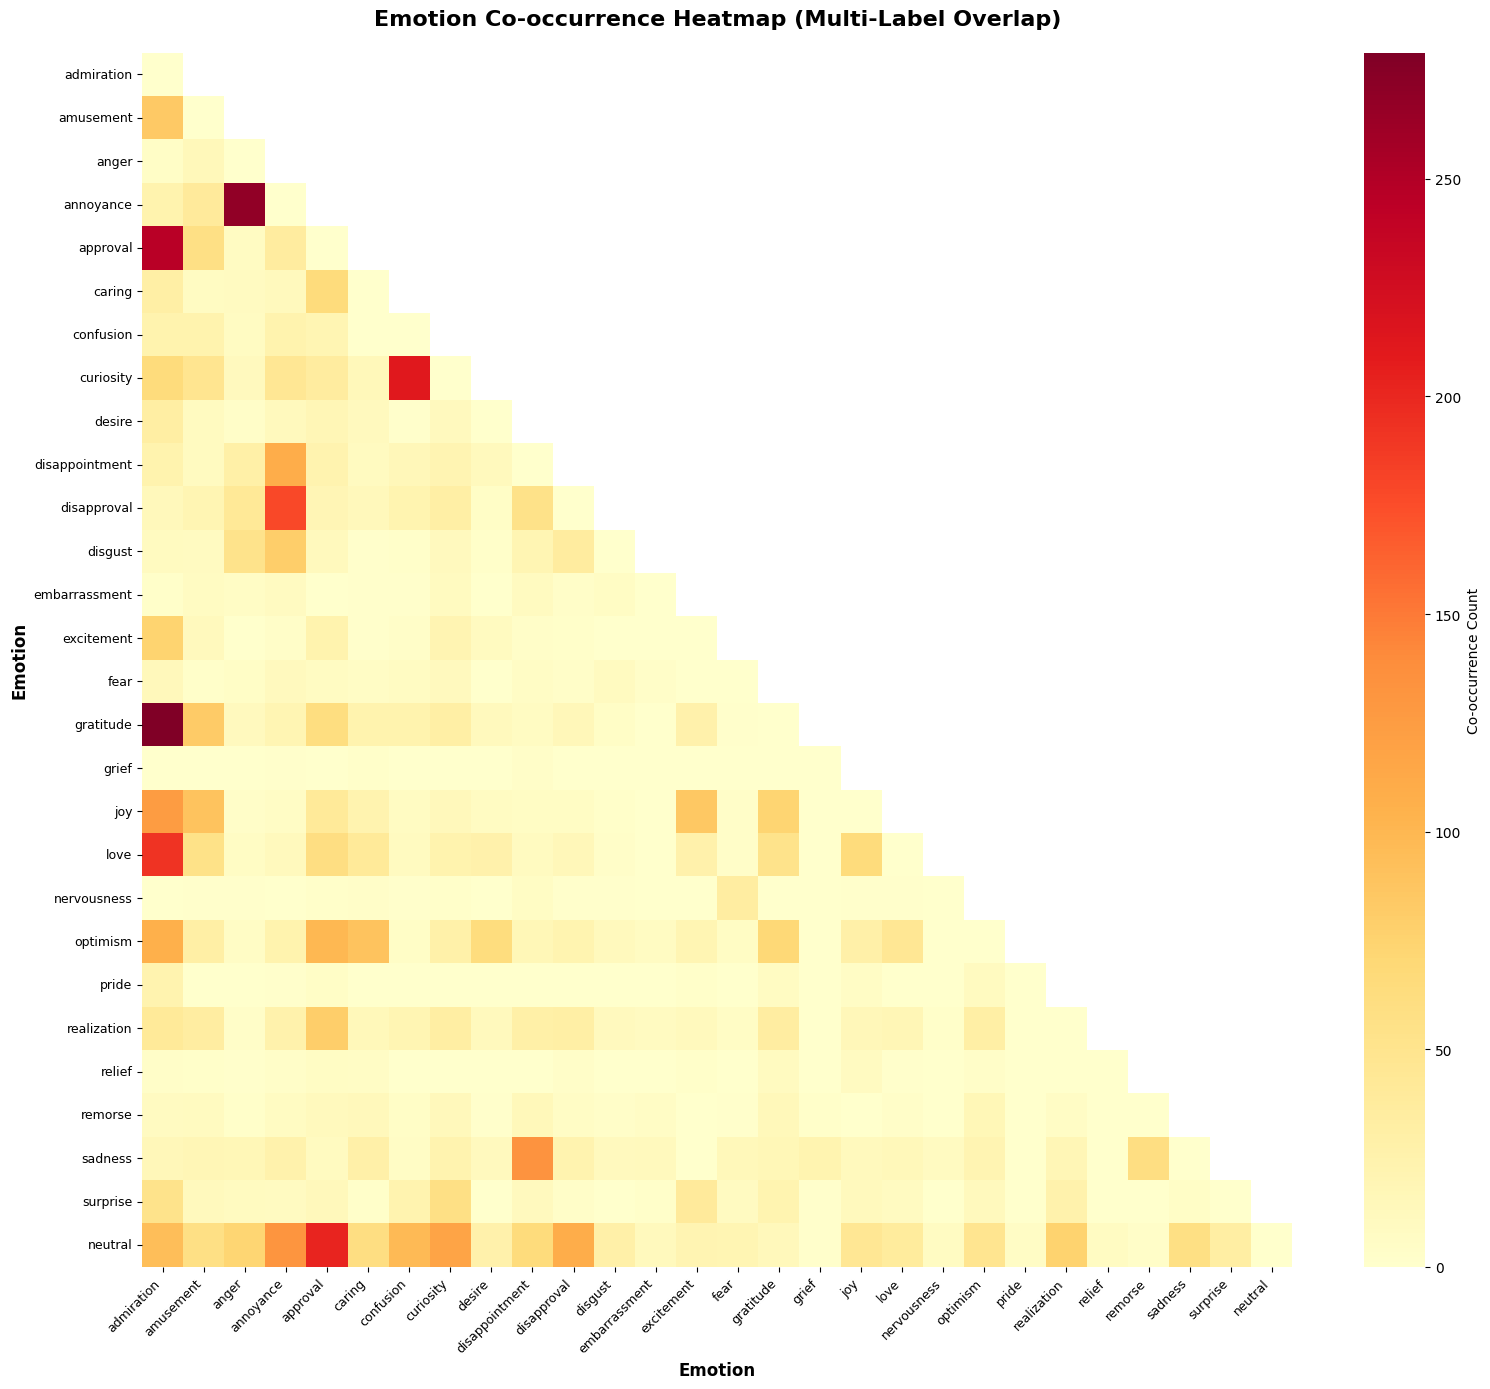

In [4]:
print("\n=== Creating Co-occurrence Matrix ===")

# Build co-occurrence matrix
cooccurrence = np.zeros((len(emotion_names), len(emotion_names)))

for labels in df['labels']:
    for i, j in combinations(labels, 2):
        cooccurrence[i, j] += 1
        cooccurrence[j, i] += 1  # Symmetric

# Create heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)
sns.heatmap(cooccurrence, mask=mask, annot=False, cmap='YlOrRd', 
            xticklabels=emotion_names, yticklabels=emotion_names,
            cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Emotion Co-occurrence Heatmap (Multi-Label Overlap)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('1_cooccurrence_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Lower-triangular heatmap illustrating the frequency of label co-occurrence across the GoEmotions dataset. The intensity of the color (white to dark red) represents the raw count of instances where two distinct emotion labels were assigned to the same text snippet. This visualization highlights the inherent multi-label complexity and semantic overlap between categories.

In [5]:
cooccur_pairs = []
for i in range(len(emotion_names)):
    for j in range(i+1, len(emotion_names)):
        if cooccurrence[i, j] > 0:
            cooccur_pairs.append((emotion_names[i], emotion_names[j], cooccurrence[i, j]))

top_pairs = sorted(cooccur_pairs, key=lambda x: x[2], reverse=True)[:10]
print("\nTop 10 Co-occurring Emotion Pairs:")
for e1, e2, count in top_pairs:
    print(f"  {e1} + {e2}: {int(count)}")


Top 10 Co-occurring Emotion Pairs:
  admiration + gratitude: 279
  anger + annoyance: 269
  admiration + approval: 246
  confusion + curiosity: 212
  approval + neutral: 202
  admiration + love: 192
  annoyance + disapproval: 178
  disappointment + sadness: 133
  annoyance + neutral: 132
  admiration + joy: 126



=== Creating UMAP Embeddings ===
Generating embeddings (this may take a few minutes)...


Batches: 100%|██████████| 157/157 [00:00<00:00, 171.62it/s]


Running UMAP dimensionality reduction...


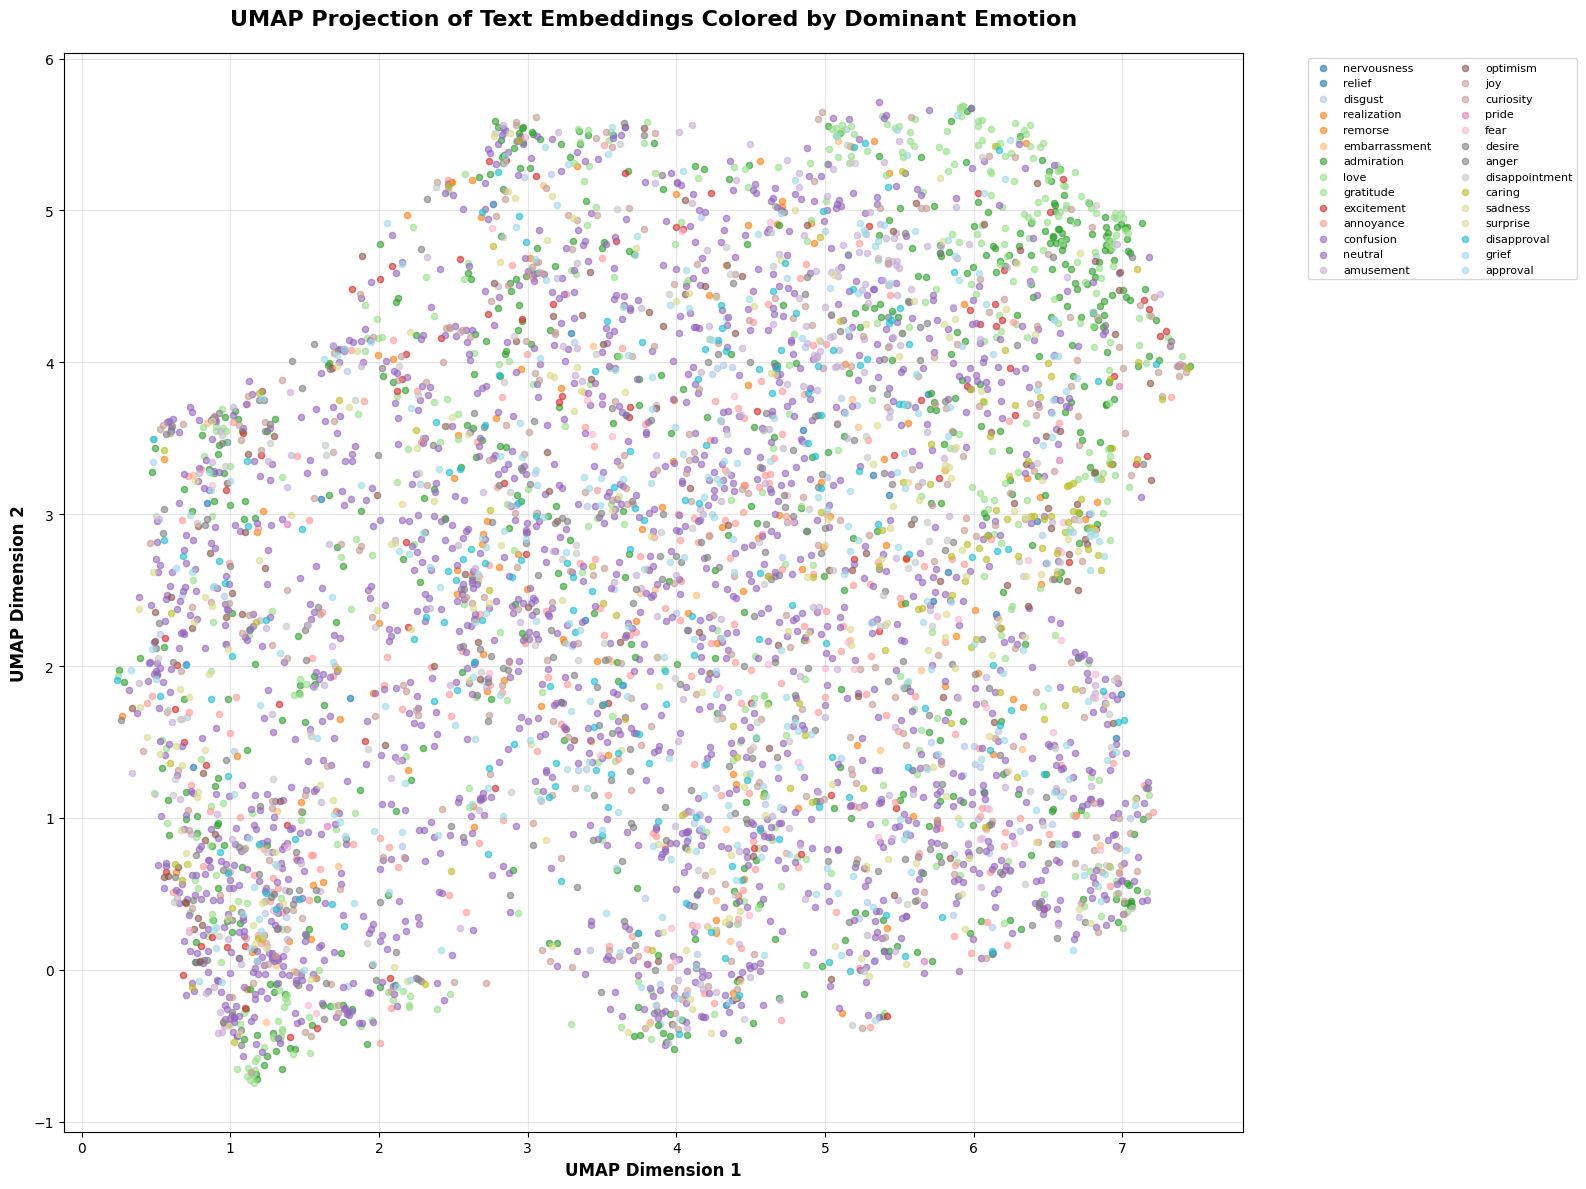

✓ UMAP visualization created


In [6]:
print("\n=== Creating UMAP Embeddings ===")

try:
    from sentence_transformers import SentenceTransformer
    import umap
    
    # Sample for faster computation (remove for full dataset)
    df_sample = df.sample(n=min(5000, len(df)), random_state=42)
    
    # Get embeddings using lightweight model
    print("Generating embeddings (this may take a few minutes)...")
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(df_sample['text'].tolist(), show_progress_bar=True)
    
    # UMAP projection
    print("Running UMAP dimensionality reduction...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Get dominant emotion for each sample
    dominant_emotions = [emotion_names[labels[0]] if len(labels) > 0 else 'neutral' 
                        for labels in df_sample['labels']]
    
    # Create UMAP plot with KDE contours
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Get unique emotions and create color map
    unique_emotions = list(set(dominant_emotions))
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_emotions)))
    color_map = dict(zip(unique_emotions, colors))
    
    # Plot points
    for emotion in unique_emotions:
        mask = [e == emotion for e in dominant_emotions]
        ax.scatter(umap_embeddings[mask, 0], umap_embeddings[mask, 1],
                  c=[color_map[emotion]], label=emotion, alpha=0.6, s=20)
    
    ax.set_title('UMAP Projection of Text Embeddings Colored by Dominant Emotion',
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('2_umap_embeddings.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ UMAP visualization created")
    
except ImportError:
    print("⚠ Install: pip install sentence-transformers umap-learn")


UMAP Visualization of GoEmotions Text Embeddings. This figure illustrates the semantic distribution of the dataset using UMAP dimensionality reduction on pre-trained transformer embeddings. The significant inter-mingling of color-coded emotion classes highlights the high degree of semantic overlap and the non-linear nature of emotion boundaries in natural language. This visualization serves as a justification for utilizing complex Neural Network architectures capable of capturing subtle linguistic nuances that traditional models typically overlook.


=== Analyzing Top Words per Emotion ===


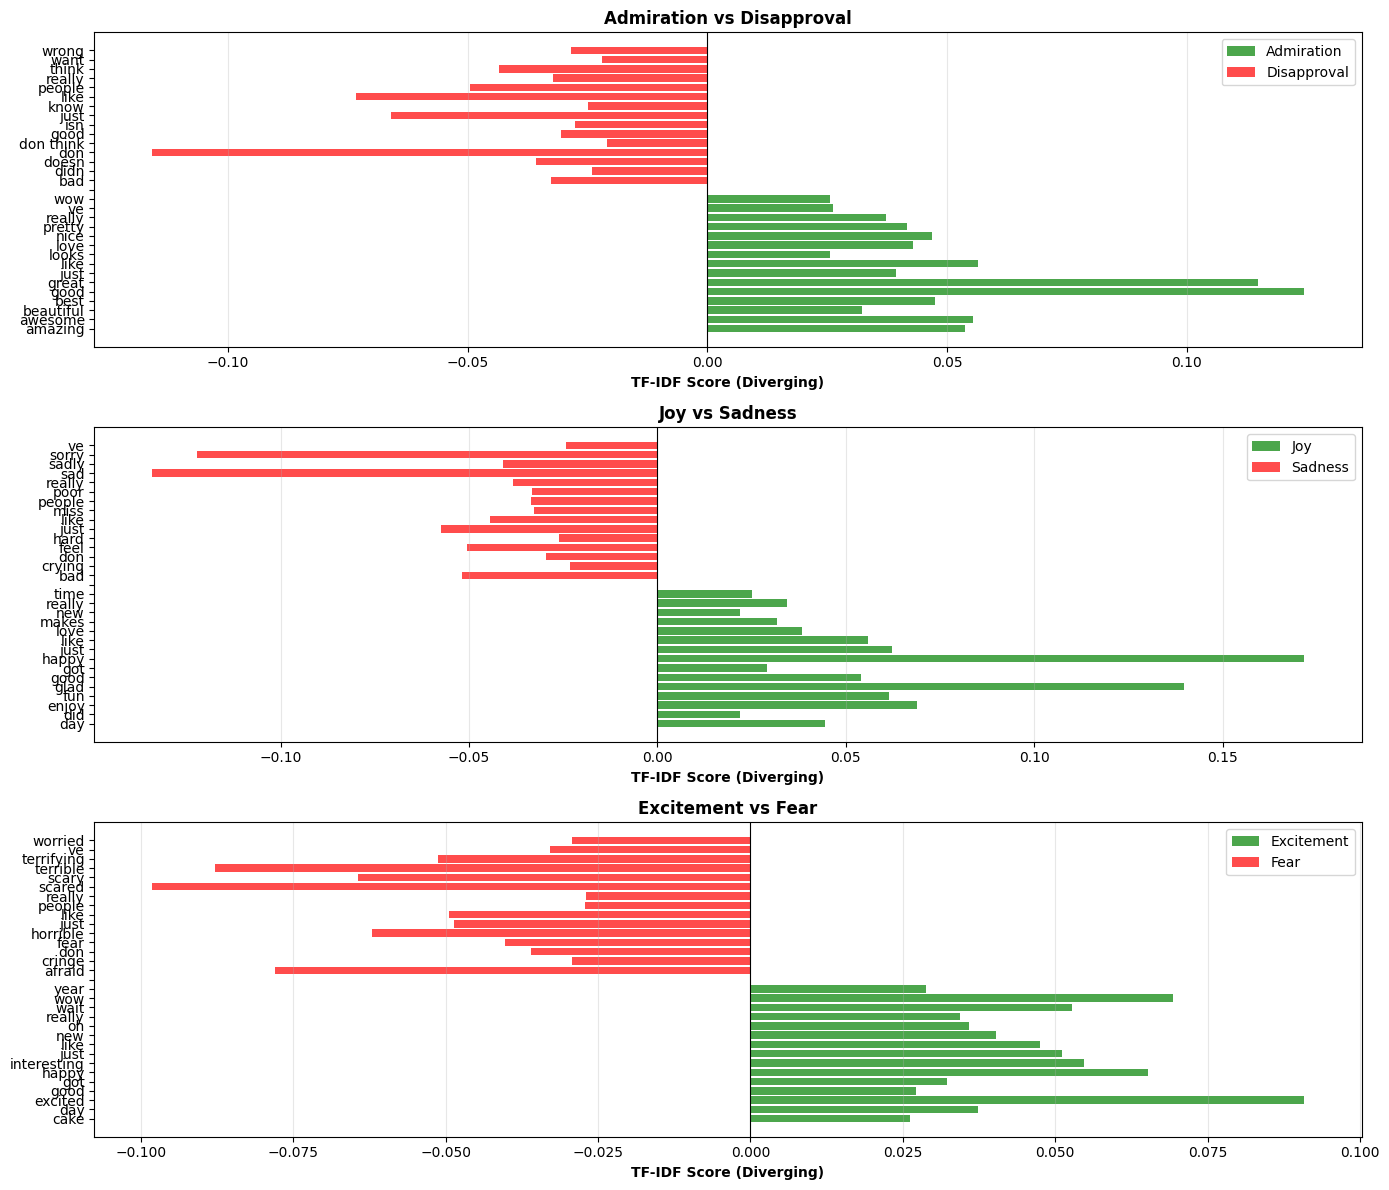

✓ TF-IDF contrast visualization created


In [7]:
print("\n=== Analyzing Top Words per Emotion ===")

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    # For each emotion, get texts containing that emotion
    emotion_texts = {emotion: [] for emotion in emotion_names}
    
    for idx, labels in enumerate(df['labels']):
        text = df.iloc[idx]['text']
        for label in labels:
            emotion_texts[emotion_names[label]].append(text)
    
    # Get top words for a few contrasting emotions
    contrasting_pairs = [('admiration', 'disapproval'), 
                        ('joy', 'sadness'),
                        ('excitement', 'fear')]
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    for idx, (pos_emotion, neg_emotion) in enumerate(contrasting_pairs):
        # Get TF-IDF for each emotion
        vectorizer = TfidfVectorizer(max_features=15, stop_words='english', 
                                     ngram_range=(1, 2))
        
        if len(emotion_texts[pos_emotion]) > 10 and len(emotion_texts[neg_emotion]) > 10:
            # Positive emotion
            tfidf_pos = vectorizer.fit_transform(emotion_texts[pos_emotion])
            words_pos = vectorizer.get_feature_names_out()
            scores_pos = tfidf_pos.mean(axis=0).A1
            
            # Negative emotion
            tfidf_neg = vectorizer.fit_transform(emotion_texts[neg_emotion])
            words_neg = vectorizer.get_feature_names_out()
            scores_neg = tfidf_neg.mean(axis=0).A1
            
            # Diverging lollipop chart
            ax = axes[idx]
            y_pos = np.arange(len(words_pos))
            y_neg = np.arange(len(words_neg))
            
            ax.barh(y_pos, scores_pos, color='green', alpha=0.7, label=pos_emotion.capitalize())
            ax.barh(y_neg + len(words_pos) + 1, -scores_neg, color='red', alpha=0.7, 
                   label=neg_emotion.capitalize())
            
            ax.set_yticks(list(y_pos) + [len(words_pos)] + list(y_neg + len(words_pos) + 1))
            ax.set_yticklabels(list(words_pos) + [''] + list(words_neg))
            ax.axvline(0, color='black', linewidth=0.8)
            ax.set_xlabel('TF-IDF Score (Diverging)', fontweight='bold')
            ax.set_title(f'{pos_emotion.capitalize()} vs {neg_emotion.capitalize()}', 
                        fontweight='bold')
            ax.legend()
            ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('3_tfidf_contrasts.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ TF-IDF contrast visualization created")
    
except Exception as e:
    print(f"⚠ Error in TF-IDF analysis: {e}")

Diverging TF-IDF Scores for Contrasting Emotion Pairs. This visualization identifies the most discriminative tokens for three key emotional polarities in the GoEmotions dataset. By calculating the TF-IDF weight of words relative to specific labels, we highlight the "lexical anchors" that define each emotion. The overlap of common functional words (e.g., "just", "really") across opposing categories demonstrates the necessity of context-aware Neural Network architectures over traditional frequency-based linguistic models.


=== Analyzing Label Distribution ===


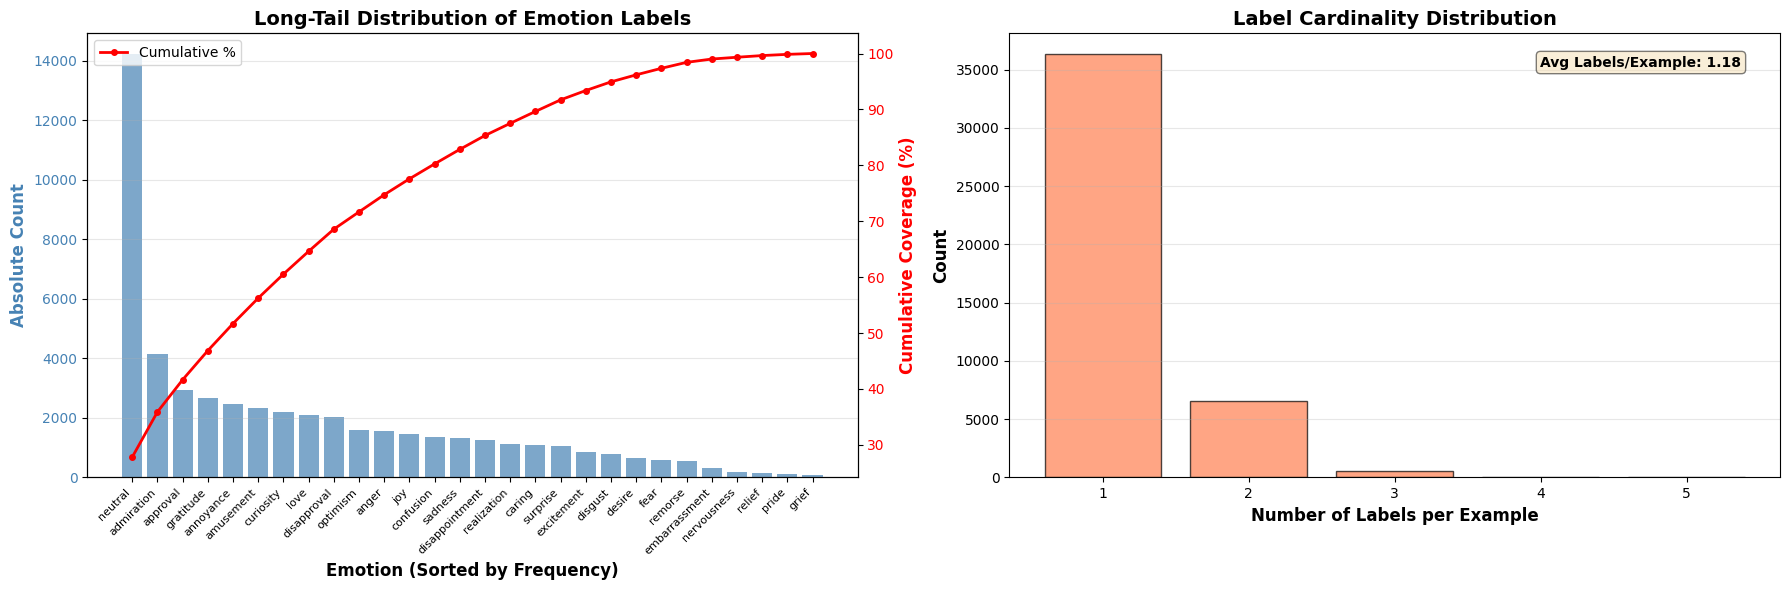


=== Summary Statistics ===
Total unique emotions: 28
Most common emotion: neutral (14219 examples)
Least common emotion: grief (77 examples)
Average labels per example: 1.18
Class imbalance ratio: 184.66x

✓ All visualizations completed!
Saved files:
  - 1_cooccurrence_heatmap.png
  - 2_umap_embeddings.png
  - 3_tfidf_contrasts.png
  - 4_label_cardinality.png


In [8]:
print("\n=== Analyzing Label Distribution ===")

# Count label frequency
label_counts = Counter()
for labels in df['labels']:
    for label in labels:
        label_counts[emotion_names[label]] += 1

# Sort by frequency
sorted_emotions = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
emotions, counts = zip(*sorted_emotions)

# Calculate cumulative coverage
total = sum(counts)
cumulative = np.cumsum(counts) / total * 100

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Long-tail distribution with cumulative line
ax1_twin = ax1.twinx()
bars = ax1.bar(range(len(emotions)), counts, color='steelblue', alpha=0.7)
line = ax1_twin.plot(range(len(emotions)), cumulative, color='red', 
                     marker='o', linewidth=2, markersize=4, label='Cumulative %')

ax1.set_xlabel('Emotion (Sorted by Frequency)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Absolute Count', fontsize=12, fontweight='bold', color='steelblue')
ax1_twin.set_ylabel('Cumulative Coverage (%)', fontsize=12, fontweight='bold', color='red')
ax1.set_title('Long-Tail Distribution of Emotion Labels', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(emotions)))
ax1.set_xticklabels(emotions, rotation=45, ha='right', fontsize=8)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.grid(axis='y', alpha=0.3)
ax1_twin.legend(loc='upper left')

# Subplot 2: Label cardinality histogram
cardinality = [len(labels) for labels in df['labels']]
cardinality_counts = Counter(cardinality)
cards = sorted(cardinality_counts.keys())
card_counts = [cardinality_counts[c] for c in cards]

ax2.bar(cards, card_counts, color='coral', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Number of Labels per Example', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Label Cardinality Distribution', fontsize=14, fontweight='bold')
ax2.set_xticks(cards)
ax2.grid(axis='y', alpha=0.3)

# Add statistics text
avg_cardinality = np.mean(cardinality)
ax2.text(0.95, 0.95, f'Avg Labels/Example: {avg_cardinality:.2f}', 
         transform=ax2.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('4_label_cardinality.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Summary Statistics ===")
print(f"Total unique emotions: {len(emotion_names)}")
print(f"Most common emotion: {sorted_emotions[0][0]} ({sorted_emotions[0][1]} examples)")
print(f"Least common emotion: {sorted_emotions[-1][0]} ({sorted_emotions[-1][1]} examples)")
print(f"Average labels per example: {avg_cardinality:.2f}")
print(f"Class imbalance ratio: {sorted_emotions[0][1] / sorted_emotions[-1][1]:.2f}x")

print("\n✓ All visualizations completed!")
print("Saved files:")
print("  - 1_cooccurrence_heatmap.png")
print("  - 2_umap_embeddings.png")
print("  - 3_tfidf_contrasts.png")
print("  - 4_label_cardinality.png")

Label Sparsity and Cardinality Analysis. The left panel illustrates a significant long-tail distribution, with "Neutral" dominating the dataset, necessitating robust class-imbalancing techniques during model training. The right panel displays label cardinality, confirming the multi-label nature of the task with an average of 1.18 labels per example. Together, these metrics define the optimization constraints for the neural network architecture.

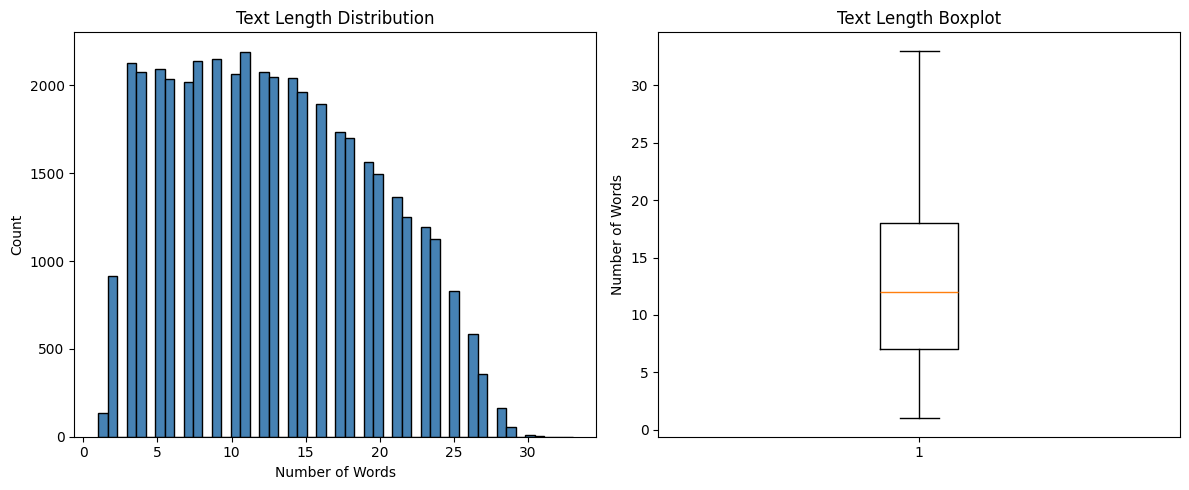

Mean length: 12.8 words
Median: 12.0 words
Max: 33 words


In [9]:
# Quick code
text_lengths = df['text'].str.split().str.len()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(text_lengths, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.title('Text Length Distribution')

plt.subplot(1, 2, 2)
plt.boxplot(text_lengths)
plt.ylabel('Number of Words')
plt.title('Text Length Boxplot')
plt.tight_layout()
plt.show()

print(f"Mean length: {text_lengths.mean():.1f} words")
print(f"Median: {text_lengths.median():.1f} words")
print(f"Max: {text_lengths.max()} words")

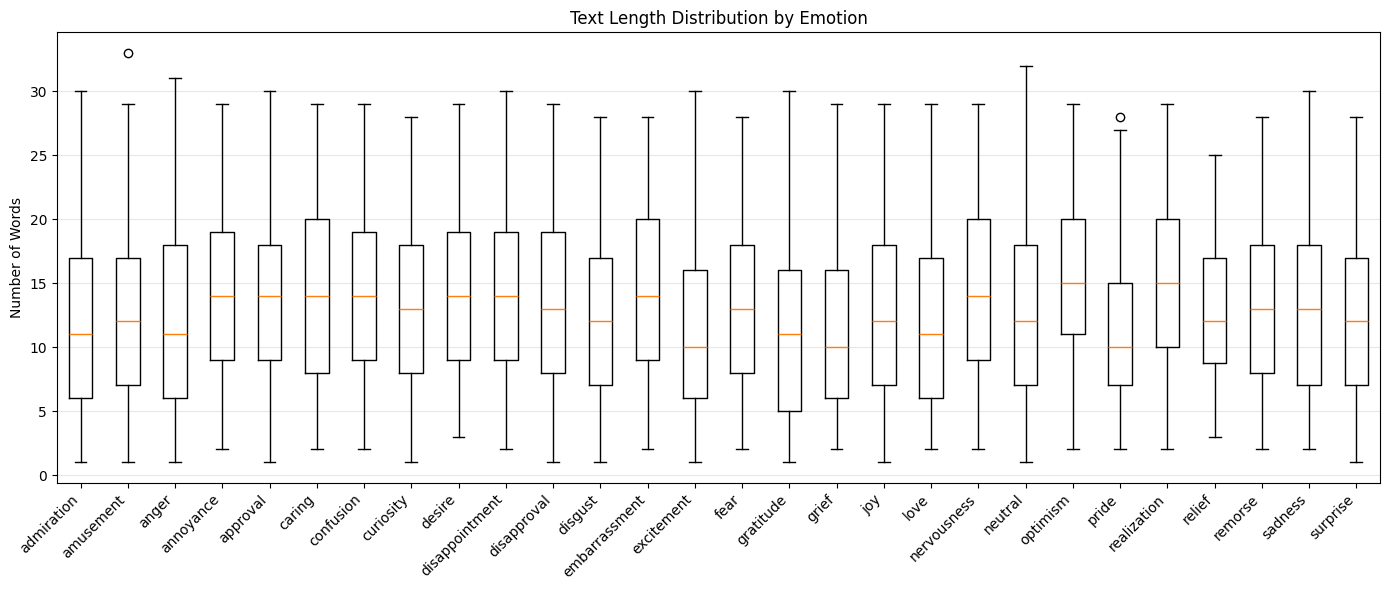

In [10]:
# Group text lengths by dominant emotion
emotion_lengths = {}
for idx, labels in enumerate(df['labels']):
    if len(labels) > 0:
        dominant = emotion_names[labels[0]]
        length = len(df.iloc[idx]['text'].split())
        if dominant not in emotion_lengths:
            emotion_lengths[dominant] = []
        emotion_lengths[dominant].append(length)

# Plot
plt.figure(figsize=(14, 6))
plt.boxplot([emotion_lengths[e] for e in sorted(emotion_lengths.keys())],
            labels=sorted(emotion_lengths.keys()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Words')
plt.title('Text Length Distribution by Emotion')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import kruskal

# Prepare data for Kruskal-Wallis test (non-parametric ANOVA)
length_groups = [emotion_lengths[e] for e in sorted(emotion_lengths.keys())]

# Test if distributions are significantly different
statistic, p_value = kruskal(*length_groups)

print(f"Kruskal-Wallis H-statistic: {statistic:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value > 0.05:
    print("✓ No significant difference in text lengths across emotions")
else:
    print("✗ Emotions have statistically different text lengths")

Kruskal-Wallis H-statistic: 869.96
P-value: 0.0000
✗ Emotions have statistically different text lengths


Loading GoEmotions dataset...

=== Dataset Split Sizes ===
Train       : 43,410 examples (80.0%)
Validation  : 5,426 examples (10.0%)
Test        : 5,427 examples (10.0%)

=== Analyzing emotion distribution across splits ===

=== Top 10 Emotions - Absolute Counts ===
             train  validation  test  Total
neutral      14219        1766  1787  17772
admiration    4130         488   504   5122
approval      2939         397   351   3687
gratitude     2662         358   352   3372
annoyance     2470         303   320   3093
amusement     2328         303   264   2895
curiosity     2191         248   284   2723
disapproval   2022         292   267   2581
love          2086         252   238   2576
optimism      1581         209   186   1976

=== Bottom 5 Emotions (Rarest) - Absolute Counts ===
               train  validation  test  Total
embarrassment    303          35    37    375
nervousness      164          21    23    208
relief           153          18    11    182
pride     

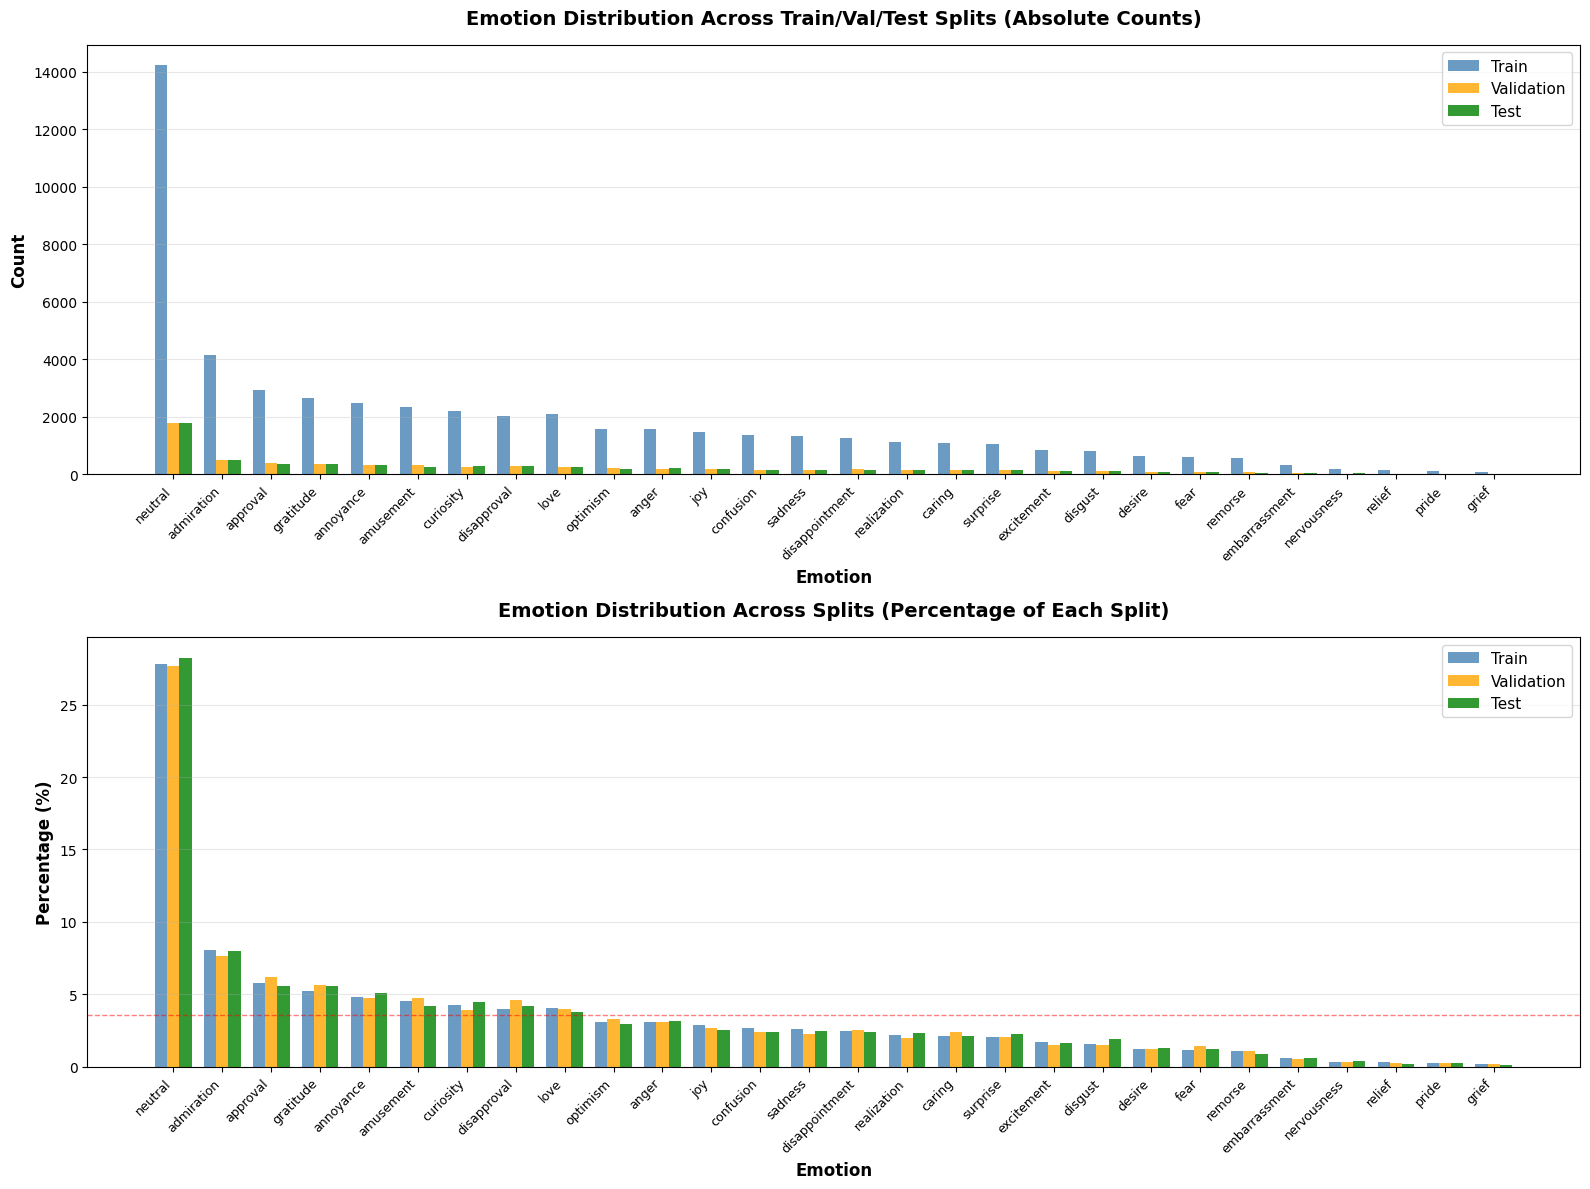


=== Checking for Zero-Shot Scenarios ===
✓ No zero-shot scenarios detected - all emotions appear in training set!

=== Split Balance Analysis ===
Jensen-Shannon Divergence (lower = more similar):
  Train vs Val:  0.0244
  Train vs Test: 0.0244
  Val vs Test:   0.0321

✓ Splits are well-balanced (JS divergence < 0.1)

=== Rare Emotion Coverage ===

Emotions with < 100 total examples:
       train  validation  test  Total
grief     77          13     6     96

=== Minimum Emotion Counts per Split ===
Train       : grief           =  77 examples
Validation  : grief           =  13 examples
Test        : grief           =   6 examples

SUMMARY FOR THESIS

1. Dataset Size:
   - Total examples: 54,263
   - Train: 43,410 (80.0%)
   - Val:   5,426 (10.0%)
   - Test:  5,427 (10.0%)

2. Split Balance:
   - JS Divergence (Train-Val): 0.0244
   - Interpretation: Well-balanced

3. Rare Emotion Coverage:
   - Emotions with <100 examples: 1
   - Smallest emotion in training: 77 examples

4. Zero-Sho

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter

print("Loading GoEmotions dataset...")
dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

# Get emotion names
emotion_names = dataset['train'].features['labels'].feature.names

# ============================================================================
# 1. SPLIT SIZE COMPARISON
# ============================================================================
splits = ['train', 'validation', 'test']
split_sizes = {split: len(dataset[split]) for split in splits}

print("\n=== Dataset Split Sizes ===")
for split, size in split_sizes.items():
    print(f"{split.capitalize():12s}: {size:,} examples ({size/sum(split_sizes.values())*100:.1f}%)")

# ============================================================================
# 2. EMOTION DISTRIBUTION ACROSS SPLITS
# ============================================================================
print("\n=== Analyzing emotion distribution across splits ===")

# Count emotions in each split
split_emotion_counts = {}
for split in splits:
    df_split = pd.DataFrame(dataset[split])
    emotion_counts = Counter()
    for labels in df_split['labels']:
        for label in labels:
            emotion_counts[emotion_names[label]] += 1
    split_emotion_counts[split] = emotion_counts

# Create comparison DataFrame
comparison_df = pd.DataFrame(split_emotion_counts).fillna(0).astype(int)
comparison_df['Total'] = comparison_df.sum(axis=1)
comparison_df = comparison_df.sort_values('Total', ascending=False)

# Calculate percentages
comparison_pct = comparison_df.copy()
for split in splits:
    comparison_pct[split] = (comparison_df[split] / comparison_df[split].sum() * 100).round(2)

print("\n=== Top 10 Emotions - Absolute Counts ===")
print(comparison_df.head(10))

print("\n=== Bottom 5 Emotions (Rarest) - Absolute Counts ===")
print(comparison_df.tail(5))

# ============================================================================
# 3. VISUALIZATION 1: Stacked Bar Chart
# ============================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Absolute counts
ax1 = axes[0]
x = np.arange(len(comparison_df))
width = 0.25

bars1 = ax1.bar(x - width, comparison_df['train'], width, label='Train', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x, comparison_df['validation'], width, label='Validation', color='orange', alpha=0.8)
bars3 = ax1.bar(x + width, comparison_df['test'], width, label='Test', color='green', alpha=0.8)

ax1.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Emotion Distribution Across Train/Val/Test Splits (Absolute Counts)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df.index, rotation=45, ha='right', fontsize=9)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Percentage distribution
ax2 = axes[1]
bars1 = ax2.bar(x - width, comparison_pct['train'], width, label='Train', color='steelblue', alpha=0.8)
bars2 = ax2.bar(x, comparison_pct['validation'], width, label='Validation', color='orange', alpha=0.8)
bars3 = ax2.bar(x + width, comparison_pct['test'], width, label='Test', color='green', alpha=0.8)

ax2.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Emotion Distribution Across Splits (Percentage of Each Split)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df.index, rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=3.57, color='red', linestyle='--', linewidth=1, alpha=0.5, 
            label='Expected (uniform: 3.57%)')

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. CHECK FOR ZERO-SHOT SCENARIOS (Critical!)
# ============================================================================
print("\n=== Checking for Zero-Shot Scenarios ===")
zero_shot_emotions = []

for emotion in emotion_names:
    train_count = comparison_df.loc[emotion, 'train'] if emotion in comparison_df.index else 0
    val_count = comparison_df.loc[emotion, 'validation'] if emotion in comparison_df.index else 0
    test_count = comparison_df.loc[emotion, 'test'] if emotion in comparison_df.index else 0
    
    if train_count == 0 and (val_count > 0 or test_count > 0):
        zero_shot_emotions.append(emotion)
        print(f"⚠️  {emotion}: Train={train_count}, Val={val_count}, Test={test_count}")

if len(zero_shot_emotions) == 0:
    print("✓ No zero-shot scenarios detected - all emotions appear in training set!")
else:
    print(f"\n⚠️  WARNING: {len(zero_shot_emotions)} emotions have zero-shot scenarios!")

# ============================================================================
# 5. SPLIT BALANCE ANALYSIS
# ============================================================================
print("\n=== Split Balance Analysis ===")

# Calculate distribution similarity (using percentage)
from scipy.spatial.distance import jensenshannon

train_dist = comparison_pct['train'].values / 100
val_dist = comparison_pct['validation'].values / 100
test_dist = comparison_pct['test'].values / 100

js_train_val = jensenshannon(train_dist, val_dist)
js_train_test = jensenshannon(train_dist, test_dist)
js_val_test = jensenshannon(val_dist, test_dist)

print(f"Jensen-Shannon Divergence (lower = more similar):")
print(f"  Train vs Val:  {js_train_val:.4f}")
print(f"  Train vs Test: {js_train_test:.4f}")
print(f"  Val vs Test:   {js_val_test:.4f}")

if js_train_val < 0.1 and js_train_test < 0.1:
    print("\n✓ Splits are well-balanced (JS divergence < 0.1)")
else:
    print("\n⚠️  Splits show some imbalance (JS divergence ≥ 0.1)")

# ============================================================================
# 6. RARE EMOTION ANALYSIS
# ============================================================================
print("\n=== Rare Emotion Coverage ===")
threshold = 100  # Define "rare" as < 100 total examples

rare_emotions = comparison_df[comparison_df['Total'] < threshold]
print(f"\nEmotions with < {threshold} total examples:")
print(rare_emotions[['train', 'validation', 'test', 'Total']])

# Check minimum counts in each split
min_counts = comparison_df[splits].min()
print(f"\n=== Minimum Emotion Counts per Split ===")
for split in splits:
    emotion = comparison_df[split].idxmin()
    count = comparison_df[split].min()
    print(f"{split.capitalize():12s}: {emotion:15s} = {int(count):3d} examples")

# ============================================================================
# 7. SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*60)
print("SUMMARY FOR THESIS")
print("="*60)

print(f"\n1. Dataset Size:")
print(f"   - Total examples: {sum(split_sizes.values()):,}")
print(f"   - Train: {split_sizes['train']:,} ({split_sizes['train']/sum(split_sizes.values())*100:.1f}%)")
print(f"   - Val:   {split_sizes['validation']:,} ({split_sizes['validation']/sum(split_sizes.values())*100:.1f}%)")
print(f"   - Test:  {split_sizes['test']:,} ({split_sizes['test']/sum(split_sizes.values())*100:.1f}%)")

print(f"\n2. Split Balance:")
print(f"   - JS Divergence (Train-Val): {js_train_val:.4f}")
print(f"   - Interpretation: {'Well-balanced' if js_train_val < 0.1 else 'Some imbalance detected'}")

print(f"\n3. Rare Emotion Coverage:")
print(f"   - Emotions with <100 examples: {len(rare_emotions)}")
print(f"   - Smallest emotion in training: {comparison_df['train'].min():.0f} examples")

print(f"\n4. Zero-Shot Risk:")
print(f"   - Emotions absent from training: {len(zero_shot_emotions)}")

print("\n✓ Split analysis complete!")
print("Generated: split_distribution.png")